# Kuramoto Fully-Connected

In [1]:
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt
import pandas as pd
import math as math
import scipy.integrate as inte
import time as tim



### Determining order parameter by consistancy equation:

According to the analytical calculation for the Lorentzian frequency distribution: $1 = \lambda/(1+\sqrt{1+(\lambda R)^2}) \implies$
$R = \sqrt{\frac{\lambda-2}{\lambda}}$

In [2]:
def Rtheo(lamb):
    if (lamb<2):
        return 0
    else:
        return np.sqrt((lamb-2)/lamb)

Rtheo = np.vectorize(Rtheo,otypes=[float])

### Numerical calculation

First we create a routine for the Kuramoto model

In [50]:
def Init(N,seed=42):
    rng = np.random.default_rng(seed)
    th0 = np.zeros(N)
    for i in range(N):
        th0[i] = rng.uniform(-np.pi,np.pi)
    return np.array([th0])

def omLtz(N): # using the Lorentzian cumulative distribution for a regular frequency sampling
    omLtz = np.zeros(N)
    for i in range(N):
        omLtz[i] = np.tan(np.pi*(i+0.5-0.5*N)/N)
    return np.array([omLtz])
    
def order(tharr):
    #N = np.size(tharr)
    #print(N)
    #Rx = np.sum(np.cos(tharr))/N
    #Ry = np.sum(np.sin(tharr))/N
    Rx = np.mean(np.cos(tharr))
    Ry = np.mean(np.sin(tharr))
    R = np.sqrt(Rx**2+Ry**2)
    phi = np.arcsin(Ry/R)
    return (R,phi)

#order = np.vectorize(order)

def fKM(lamb,tharr):
    N = np.size(tharr)
    #R, phi = order(tharr)
    Rx = np.mean(np.cos(tharr))
    Ry = np.mean(np.sin(tharr))
    R = np.sqrt(Rx**2+Ry**2)
    phi = np.arcsin(Ry/R)
    velarr = lamb*R*np.sin(phi-tharr)
    
    return velarr

def time_interval(dt,tf):
    Nt = int(tf/dt)+1
    time = np.linspace(0,tf,Nt)
    return (time,dt)
    
    
def integ(time,lamb,omarr,thini): #Heun method of integration
    N = np.size(thini)
    timelist, dt = time
    #print(dt)
    Nt = np.size(timelist)
    integ = np.zeros([Nt,2,N])
    #print(integ[0,:,:])
    #print(np.array([thini,fKM(lamb,omarr,thini)]))
    
    integ[0,:,:] = np.array([thini[0],(omarr+fKM(lamb,thini))[0]])
    th = thini
    
    
    for i in range(1,Nt):
        velaux = omarr + fKM(lamb,th)
        #thaux = th + dt*velaux
        #vel = (fKM(lamb,omarr,th)+fKM(lamb,omarr,th + dt*velaux))/2.
        #th = np.remainder(th + dt*(omarr + 0.5*(fKM(lamb,th)+fKM(lamb,th + dt*velaux))),2*np.pi) 
        th = np.remainder(th + dt*(0.5*(omarr+velaux+fKM(lamb,th + dt*velaux))),2*np.pi) 

        integ[i,:,:] = np.array([th[0],velaux[0]])
    return integ

In [33]:
N = 10000
omlist = omLtz(N)
th0 = Init(N,30)
lamb = 2.3
time = time_interval(0.01,500)
Nt = np.size(time[0])

f1 = fKM(lamb,th0)
#result = integ(time,lamb,omlist,th0)

In [34]:
start_time = tim.perf_counter()

result = integ(time,lamb,omlist,th0)

end_time = tim.perf_counter()
elapsed_time = end_time - start_time
print(f"Elapsed execution time: {elapsed_time:.6f} seconds")

Elapsed execution time: 91.053387 seconds


In [39]:
final = result[-1,:,:]
final

array([[ 1.07391543e+00,  2.52835723e+00,  1.57924550e-01, ...,
         6.05884136e+00,  4.36059967e+00,  2.69812980e-01],
       [-6.36657759e+03, -2.12179572e+03, -1.27249598e+03, ...,
         1.27404122e+03,  2.12162249e+03,  6.36695274e+03]])

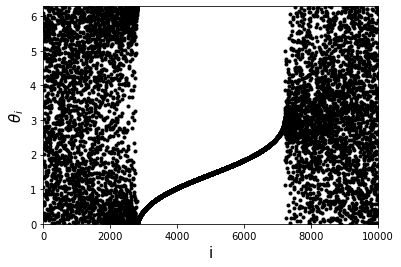

In [72]:
final = result[-1,:,:]
index = np.arange(N)

plt.scatter(index,final[0],marker='.',color='black')
plt.ylabel(r"$\theta_i$",size=15)
plt.xlabel(r"i",size=15)
plt.xlim(0,N)
plt.ylim(0,6.28)
plt.savefig("KuramotoSolution-theta.pdf",bbox_inches='tight')

In [49]:
with open('KuramotoSolution.dat', 'w') as f:
    f.write("i theta vel\n")
    for i in range(N):
        f.write(str(i+1)+" "+str(final[0,i])+" "+str(final[1,i])+"\n")

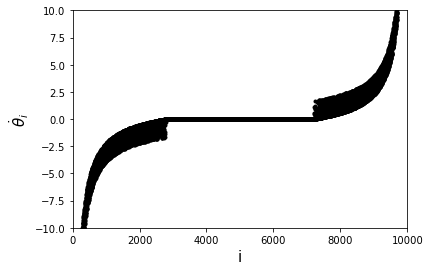

In [73]:
plt.scatter(index,final[1],marker='.',color='black')
#plt.yscale('log')
plt.ylim(-10,10)
plt.xlim(0,N)
plt.ylabel(r"$\dot{\theta}_i$",size=15)
plt.xlabel(r"i",size=15)
plt.savefig("KuramotoSolution-vel.pdf",bbox_inches='tight')

In [66]:
Rlist = np.zeros(Nt)
philist = np.zeros(Nt)

for i in range(Nt):
    Rlist[i], philist[i] = order(result[i,0,:])


#Rlist, philist = order(result[-1,0,:])

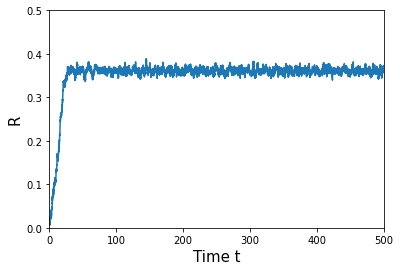

In [74]:
plt.plot(time[0],Rlist)
plt.ylim(0,0.5)
plt.xlim(0,500)
plt.ylabel('R',size=15)
plt.xlabel("Time t",size=15)

plt.savefig("Kuramoto-fully-transition.pdf",bbox_inches='tight')

In [75]:
with open('KuramotoTime.dat', 'w') as f:
    f.write("i R \phi\n")
    for i in range(Nt):
        f.write(str(i+1)+" "+str(Rlist[i])+" "+str(philist[i])+"\n")

## Critical coupling

In [76]:
N = 10000
omlist = omLtz(N)
th0 = Init(N,10)
time = time_interval(0.01,50)
Nt = np.size(time[0])

Nlamb = 40
lamblist = np.linspace(0.1,10,Nlamb)
Rlist = np.zeros(Nlamb)



In [77]:
for i in range(Nlamb):
    result = integ(time,lamblist[i],omlist,th0)
    R, phi = order(result[-1,0,:])
    Rlist[i] = R
#result = integ(time,lamb,omlist,th0)

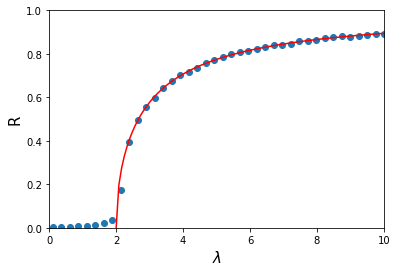

In [80]:

plt.scatter(lamblist,Rlist)
plt.plot(np.linspace(2,10,100),Rtheo(np.linspace(2,10,100)),color='red')
plt.ylim(0,1)
plt.xlim(0,10)
plt.ylabel('R',size=15)
plt.xlabel(r"$\lambda$",size=15)

plt.savefig("Kuramoto-fully-transition.pdf")

In [81]:
with open('KuramotoTransition.dat', 'w') as f:
    f.write("\lambda R\n")
    for i in range(Nlamb):
        f.write(str(lamblist[i])+" "+str(Rlist[i])+"\n")
